In [2]:
import os
import re
from collections import defaultdict

import ROOT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from idm_plot_utils import *

setup_root_style()

INPUT = "root://cmseos.fnal.gov//store/group/lpcmetx/iDMe/Samples/Ntuples/signal_iDMmu_muonBranches_inclusive/2022EE/iDMmu"
TREE_NAME = "ntuples/outT"

OUTDIR = "matching_efficiency_w_cuts"
os.makedirs(OUTDIR, exist_ok=True)


MATCH_DR_MAX_DSA= 0.15

MATCH_DR_MAX_GM = 0.06

GEN_MUON_PT_MIN = 5.0
GEN_MUON_ABS_ETA_MAX = 2.4

GEN_MUON_VXY_MAX= 740.0

GEN_MUON_ABS_VZ_MAX= 960.0

In [3]:
files, sample_to_files, samples = load_samples(INPUT)

print(f"Found {len(samples)} samples")
for s in samples:
    print(s, len(sample_to_files[s]))

chain_test = make_chain(sample_to_files[samples[0]], tree_name=TREE_NAME)

print("\nDSA-related branches:")
for b in chain_test.GetListOfBranches():
    name = b.GetName()
    if "DSA" in name or "dsa" in name:
        print(name)

print("\nGenParticle vertex-related branches:")
for b in chain_test.GetListOfBranches():
    name = b.GetName()
    lname = name.lower()
    if "genparticle" in lname and ("vx" in lname or "vy" in lname or "vz" in lname or "vxy" in lname):
        print(name)

Found 138 ROOT files
Found 20 grouped samples
Mchi-5p25_dMchi-0p5_ctau-1           nfiles = 8
Mchi-5p25_dMchi-0p5_ctau-10          nfiles = 8
Mchi-5p25_dMchi-0p5_ctau-100         nfiles = 8
Mchi-5p25_dMchi-0p5_ctau-1000        nfiles = 5
Mchi-10p5_dMchi-1p0_ctau-1           nfiles = 8
Mchi-10p5_dMchi-1p0_ctau-10          nfiles = 4
Mchi-10p5_dMchi-1p0_ctau-100         nfiles = 4
Mchi-10p5_dMchi-1p0_ctau-1000        nfiles = 7
Mchi-21p0_dMchi-2p0_ctau-1           nfiles = 7
Mchi-21p0_dMchi-2p0_ctau-10          nfiles = 8
Mchi-21p0_dMchi-2p0_ctau-100         nfiles = 7
Mchi-21p0_dMchi-2p0_ctau-1000        nfiles = 8
Mchi-31p5_dMchi-3p0_ctau-1           nfiles = 6
Mchi-31p5_dMchi-3p0_ctau-10          nfiles = 6
Mchi-31p5_dMchi-3p0_ctau-100         nfiles = 7
Mchi-31p5_dMchi-3p0_ctau-1000        nfiles = 8
Mchi-42p0_dMchi-4p0_ctau-1           nfiles = 6
Mchi-42p0_dMchi-4p0_ctau-10          nfiles = 8
Mchi-42p0_dMchi-4p0_ctau-100         nfiles = 7
Mchi-42p0_dMchi-4p0_ctau-1000        nfile

In [4]:
DSA_ID_BRANCH_CANDIDATES = [
   "recoDSAMuonDisplacedId"
]


def has_branch(chain, name):
    return bool(chain.GetBranch(name))


def first_existing_branch(chain, candidates, required=False):
    for name in candidates:
        if has_branch(chain, name):
            return name

    if required:
        print("Missing required branch. Tried:")
        for name in candidates:
            print("  ", name)
        raise RuntimeError("Required branch not found")

    return None


def detect_branches_with_dsa_id_and_gen_vertex(chain):
    br = {}

    br["run"] = first_existing_branch(chain, ["runNum", "run"])
    br["lumi"] = first_existing_branch(chain, ["lumiSec", "lumi"])
    br["event"] = first_existing_branch(chain, ["eventNum", "event"])

    br["GenSigDimuon_isValid"] = first_existing_branch(
        chain,
        ["GenSigDimuon_isValid", "genSigDimuon_isValid"],
        required=True,
    )

    br["genSigDimuon_dr"] = first_existing_branch(
        chain,
        ["genSigDimuon_dr", "GenSigDimuon_dr"],
        required=True,
    )

    br["nGenParticle"] = first_existing_branch(
        chain,
        ["nGenParticle"],
        required=True,
    )

    br["GenParticle_ID"] = first_existing_branch(
        chain,
        ["GenParticle_ID", "genPartID"],
        required=True,
    )

    br["GenParticle_status"] = first_existing_branch(
        chain,
        ["GenParticle_status", "genPartStatus"],
        required=True,
    )

    br["GenParticle_isLastCopy"] = first_existing_branch(
        chain,
        ["GenParticle_isLastCopy", "genPartIsLastCopy"],
        required=True,
    )

    br["GenParticle_firstDifferentMotherID"] = first_existing_branch(
        chain,
        ["GenParticle_firstDifferentMotherID", "genPartFirstDifferentMotherID"],
        required=True,
    )

    br["GenParticle_charge"] = first_existing_branch(
        chain,
        ["GenParticle_charge", "genPartCharge"],
        required=True,
    )

    br["GenParticle_pt"] = first_existing_branch(
        chain,
        ["GenParticle_pt", "genPartPt"],
        required=True,
    )

    br["GenParticle_eta"] = first_existing_branch(
        chain,
        ["GenParticle_eta", "genPartEta"],
        required=True,
    )

    br["GenParticle_phi"] = first_existing_branch(
        chain,
        ["GenParticle_phi", "genPartPhi"],
        required=True,
    )

    br["GenParticle_vx"] = first_existing_branch(
        chain,
        [
            "GenParticle_vx",
            "GenParticle_vx_",
            "genParticle_vx",
            "genPartVx",
            "genPart_vx",
            "GenPart_vx",
        ],
        required=True,
    )

    br["GenParticle_vy"] = first_existing_branch(
        chain,
        [
            "GenParticle_vy",
            "GenParticle_vy_",
            "genParticle_vy",
            "genPartVy",
            "genPart_vy",
            "GenPart_vy",
        ],
        required=True,
    )

    br["GenParticle_vz"] = first_existing_branch(
        chain,
        [
            "GenParticle_vz",
            "GenParticle_vz_",
            "genParticle_vz",
            "genPartVz",
            "genPart_vz",
            "GenPart_vz",
        ],
        required=True,
    )

    br["recoMuonPt"] = first_existing_branch(
        chain,
        ["recoMuonPt", "recoMuonPt_", "RecoMuonPt", "Muon_pt", "MuonPt"],
        required=True,
    )

    br["recoMuonEta"] = first_existing_branch(
        chain,
        ["recoMuonEta", "recoMuonEta_", "RecoMuonEta", "Muon_eta", "MuonEta"],
        required=True,
    )

    br["recoMuonPhi"] = first_existing_branch(
        chain,
        ["recoMuonPhi", "recoMuonPhi_", "RecoMuonPhi", "Muon_phi", "MuonPhi"],
        required=True,
    )

    br["recoMuonCharge"] = first_existing_branch(
        chain,
        ["recoMuonCharge", "recoMuonCharge_", "RecoMuonCharge", "Muon_charge", "MuonCharge"],
        required=True,
    )

    br["recoDSAMuonPt"] = first_existing_branch(
        chain,
        ["recoDSAMuonPt", "recoDSAMuonPt_", "RecoDSAMuonPt", "DSAMuon_pt", "DSAMuonPt"],
        required=True,
    )

    br["recoDSAMuonEta"] = first_existing_branch(
        chain,
        ["recoDSAMuonEta", "recoDSAMuonEta_", "RecoDSAMuonEta", "DSAMuon_eta", "DSAMuonEta"],
        required=True,
    )

    br["recoDSAMuonPhi"] = first_existing_branch(
        chain,
        ["recoDSAMuonPhi", "recoDSAMuonPhi_", "RecoDSAMuonPhi", "DSAMuon_phi", "DSAMuonPhi"],
        required=True,
    )

    br["recoDSAMuonCharge"] = first_existing_branch(
        chain,
        ["recoDSAMuonCharge", "recoDSAMuonCharge_", "RecoDSAMuonCharge", "DSAMuon_charge", "DSAMuonCharge"],
        required=True,
    )

    br["recoDSAMuonPassID"] = first_existing_branch(
        chain,
        DSA_ID_BRANCH_CANDIDATES,
        required=True,
    )

    return br

In [5]:
def scalar_bool(x):
    try:
        return bool(int(x))
    except Exception:
        return bool(x)


def scalar_float(x, default=-999.0):
    try:
        return float(x)
    except Exception:
        return default


def scalar_int(x, default=-999):
    try:
        return int(x)
    except Exception:
        return default


def vec_size(v):
    if v is None:
        return 0
    if hasattr(v, "size"):
        return int(v.size())
    return len(v)


def get_scalar(chain, branch_name, default=-999):
    if branch_name is None:
        return default
    try:
        return getattr(chain, branch_name)
    except Exception:
        return default


def get_vector(chain, branch_name):
    if branch_name is None:
        return None
    try:
        return getattr(chain, branch_name)
    except Exception:
        return None


def pdgid_to_charge(pid):
    pid = int(pid)
    if pid == 13:
        return -1
    if pid == -13:
        return +1
    return 0


ROOT.gInterpreter.Declare("""
#include "DataFormats/Math/interface/deltaR.h"

float deltaR_eta_phi_wrapper(float eta1, float phi1, float eta2, float phi2) {
    return reco::deltaR(eta1, phi1, eta2, phi2);
}
""")


def root_delta_r(eta1, phi1, eta2, phi2):
    return float(
        ROOT.deltaR_eta_phi_wrapper(
            float(eta1),
            float(phi1),
            float(eta2),
            float(phi2),
        )
    )


def closest_same_sign_reco_root_delta_r(
    gen_eta,
    gen_phi,
    gen_charge,
    reco_etas,
    reco_phis,
    reco_charges,
    reco_pass_id=None,
    require_pass_id=False,
    dr_max=0.3,
):
    best_dr = 999.0
    best_idx = -1

    n_reco = vec_size(reco_etas)

    for i in range(n_reco):
        if require_pass_id:
            if reco_pass_id is None:
                continue
            if not bool(int(reco_pass_id[i])):
                continue

        reco_charge = int(reco_charges[i])

        if reco_charge != int(gen_charge):
            continue

        dr = root_delta_r(
            gen_eta,
            gen_phi,
            float(reco_etas[i]),
            float(reco_phis[i]),
        )

        if dr < best_dr:
            best_dr = dr
            best_idx = i

    matched = int(best_idx >= 0 and best_dr < dr_max)

    return {
        "matched": matched,
        "min_dr": best_dr,
        "idx": best_idx,
    }


def either_min_dr(min_dr_pf, min_dr_dsa):
    vals = []

    if min_dr_pf >= 0.0 and min_dr_pf < 900.0:
        vals.append(min_dr_pf)

    if min_dr_dsa >= 0.0 and min_dr_dsa < 900.0:
        vals.append(min_dr_dsa)

    return min(vals) if vals else 999.0

In [6]:
GEN_MUON_VXY_MAX = 740.0
GEN_MUON_ABS_VZ_MAX = 960.0


def add_genparticle_lastcopy_muon_rows_manual_dsa_id_gen_cuts(rows, chain, br, sample, entry):
    if not scalar_bool(get_scalar(chain, br["GenSigDimuon_isValid"])):
        return

    dimuon_dr = scalar_float(get_scalar(chain, br["genSigDimuon_dr"]))

    reco_pf_eta = get_vector(chain, br["recoMuonEta"])
    reco_pf_phi = get_vector(chain, br["recoMuonPhi"])
    reco_pf_charge = get_vector(chain, br["recoMuonCharge"])

    reco_dsa_eta = get_vector(chain, br["recoDSAMuonEta"])
    reco_dsa_phi = get_vector(chain, br["recoDSAMuonPhi"])
    reco_dsa_charge = get_vector(chain, br["recoDSAMuonCharge"])
    reco_dsa_pass_id = get_vector(chain, br["recoDSAMuonPassID"])

    n_gen = scalar_int(get_scalar(chain, br["nGenParticle"]))

    gen_id = get_vector(chain, br["GenParticle_ID"])
    gen_status = get_vector(chain, br["GenParticle_status"])
    gen_is_last_copy = get_vector(chain, br["GenParticle_isLastCopy"])
    gen_first_diff_mother = get_vector(chain, br["GenParticle_firstDifferentMotherID"])
    gen_charge = get_vector(chain, br["GenParticle_charge"])
    gen_pt = get_vector(chain, br["GenParticle_pt"])
    gen_eta = get_vector(chain, br["GenParticle_eta"])
    gen_phi = get_vector(chain, br["GenParticle_phi"])
    gen_vx = get_vector(chain, br["GenParticle_vx"])
    gen_vy = get_vector(chain, br["GenParticle_vy"])
    gen_vz = get_vector(chain, br["GenParticle_vz"])

    for i in range(n_gen):
        pid = int(gen_id[i])

        if abs(pid) != 13:
            continue

        if int(gen_status[i]) != 1:
            continue

        if not bool(int(gen_is_last_copy[i])):
            continue

        pt = float(gen_pt[i])
        eta = float(gen_eta[i])
        phi = float(gen_phi[i])

        vx = float(gen_vx[i])
        vy = float(gen_vy[i])
        vz = float(gen_vz[i])
        vxy = np.sqrt(vx * vx + vy * vy)

        if pt <= GEN_MUON_PT_MIN:
            continue

        if abs(eta) >= GEN_MUON_ABS_ETA_MAX:
            continue

        if vxy >= GEN_MUON_VXY_MAX:
            continue

        if abs(vz) >= GEN_MUON_ABS_VZ_MAX:
            continue

        q = int(gen_charge[i])

        if q == 0:
            q = pdgid_to_charge(pid)

        match_pf = closest_same_sign_reco_root_delta_r(
            eta,
            phi,
            q,
            reco_pf_eta,
            reco_pf_phi,
            reco_pf_charge,
            reco_pass_id=None,
            require_pass_id=False,
            dr_max=MATCH_DR_MAX_GM,
        )

        match_dsa = closest_same_sign_reco_root_delta_r(
            eta,
            phi,
            q,
            reco_dsa_eta,
            reco_dsa_phi,
            reco_dsa_charge,
            reco_pass_id=reco_dsa_pass_id,
            require_pass_id=True,
            dr_max=MATCH_DR_MAX_DSA,
        )

        min_dr_pf = match_pf["min_dr"]
        min_dr_dsa = match_dsa["min_dr"]

        rows.append(
            {
                "sample": sample,
                "entry": entry,
                "match_dr_max_gm": MATCH_DR_MAX_GM,
                "match_dr_max_dsa": MATCH_DR_MAX_DSA,

                "gen_collection": "GenParticleLastCopy",
                "gen_object": "GenParticleMuon" if pid == 13 else "GenParticleAntiMuon",
                "gen_idx": i,
                "gen_pdgId": pid,
                "gen_charge": q,

                "gen_pt": pt,
                "gen_eta": eta,
                "gen_phi": phi,

                "gen_vx": vx,
                "gen_vy": vy,
                "gen_vz": vz,
                "gen_vxy": vxy,

                "gen_firstDifferentMotherID": int(gen_first_diff_mother[i]),
                "genSigDimuon_dr": dimuon_dr,

                "minDr_PF": min_dr_pf,
                "minDr_DSA": min_dr_dsa,
                "minDr_either": either_min_dr(min_dr_pf, min_dr_dsa),

                "matched_PF": int(match_pf["matched"]),
                "matched_DSA": int(match_dsa["matched"]),
                "matched_either": int(match_pf["matched"] or match_dsa["matched"]),

                "matchIdx_PF": match_pf["idx"],
                "matchIdx_DSA": match_dsa["idx"],

                "gen_muon_pt_min": GEN_MUON_PT_MIN,
                "gen_muon_abs_eta_max": GEN_MUON_ABS_ETA_MAX,
                "gen_muon_vxy_max": GEN_MUON_VXY_MAX,
                "gen_muon_abs_vz_max": GEN_MUON_ABS_VZ_MAX,

                "matching_source": "same_sign_GMdR0p06_DSAIDdR0p15_genPt5_absEta2p4_vxy740_absVz960",
            }
        )

In [7]:
CACHE_DIR = "matching_efficiency_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

sample_cache_dir = os.path.join(
    CACHE_DIR,
    "per_sample_pkl_GMdR0p06_DSAdR0p15_dsaID_genPt5_absEta2p4_vxy740_absVz960",
)
os.makedirs(sample_cache_dir, exist_ok=True)

all_sample_dfs = []

for sample in samples:
    safe_sample = re.sub(r"[^a-zA-Z0-9_]+", "_", sample)
    sample_cache_path = os.path.join(sample_cache_dir, f"{safe_sample}.pkl")

    if os.path.exists(sample_cache_path):
        print(f"Loading cached {sample}")
        df_sample = pd.read_pickle(sample_cache_path)
        all_sample_dfs.append(df_sample)
        continue

    rows_sample = []

    chain = make_chain(sample_to_files[sample], tree_name=TREE_NAME)
    br = detect_branches_with_dsa_id_and_gen_vertex(chain)

    chain.SetBranchStatus("*", 0)

    for b in br.values():
        if b is not None:
            chain.SetBranchStatus(b, 1)

    n_entries = chain.GetEntries()

    print(f"Processing {sample:35s}  events = {n_entries}")

    for entry in range(n_entries):
        chain.GetEntry(entry)

        add_genparticle_lastcopy_muon_rows_manual_dsa_id_gen_cuts(
            rows_sample,
            chain,
            br,
            sample,
            entry,
        )

        if entry % 5000 == 0 and entry > 0:
            print(f"  processed {entry}/{n_entries}")

    df_sample = pd.DataFrame(rows_sample)

    df_sample.to_pickle(sample_cache_path)
    print(f"Saved cached sample: {sample_cache_path}")

    all_sample_dfs.append(df_sample)

df_match = pd.concat(all_sample_dfs, ignore_index=True)

df_match_path = os.path.join(
    CACHE_DIR,
    "df_match_GMdR0p06_DSAdR0p15_dsaID_genPt5_absEta2p4_vxy740_absVz960.pkl",
)

df_match.to_pickle(df_match_path)

print()
print(f"Saved: {df_match_path}")
print(f"Rows = {len(df_match)}")
df_match.head()

Processing Mchi-5p25_dMchi-0p5_ctau-1           events = 30000
  processed 5000/30000
  processed 10000/30000
  processed 15000/30000
  processed 20000/30000
  processed 25000/30000
Saved cached sample: matching_efficiency_cache/per_sample_pkl_GMdR0p06_DSAdR0p15_dsaID_genPt5_absEta2p4_vxy740_absVz960/Mchi_5p25_dMchi_0p5_ctau_1.pkl
Processing Mchi-5p25_dMchi-0p5_ctau-10          events = 30000
  processed 5000/30000
  processed 10000/30000
  processed 15000/30000
  processed 20000/30000
  processed 25000/30000
Saved cached sample: matching_efficiency_cache/per_sample_pkl_GMdR0p06_DSAdR0p15_dsaID_genPt5_absEta2p4_vxy740_absVz960/Mchi_5p25_dMchi_0p5_ctau_10.pkl
Processing Mchi-5p25_dMchi-0p5_ctau-100         events = 30000
  processed 5000/30000
  processed 10000/30000
  processed 15000/30000
  processed 20000/30000
  processed 25000/30000
Saved cached sample: matching_efficiency_cache/per_sample_pkl_GMdR0p06_DSAdR0p15_dsaID_genPt5_absEta2p4_vxy740_absVz960/Mchi_5p25_dMchi_0p5_ctau_100.pk

,sample,entry,match_dr_max_gm,match_dr_max_dsa,gen_collection,gen_object,gen_idx,gen_pdgId,gen_charge,gen_pt,...,matched_PF,matched_DSA,matched_either,matchIdx_PF,matchIdx_DSA,gen_muon_pt_min,gen_muon_abs_eta_max,gen_muon_vxy_max,gen_muon_abs_vz_max,matching_source
0,Mchi-5p25_dMchi-0p5_ctau-1,0,0.06,0.15,GenParticleLastCopy,GenParticleAntiMuon,12,-13,1,5.697460,...,1,1,1,0,0,5.0,2.4,740.0,960.0,same_sign_GMdR0p06_DSAIDdR0p15_genPt5_absEta2p...
1,Mchi-5p25_dMchi-0p5_ctau-1,0,0.06,0.15,GenParticleLastCopy,GenParticleMuon,13,13,-1,7.068364,...,1,0,1,1,1,5.0,2.4,740.0,960.0,same_sign_GMdR0p06_DSAIDdR0p15_genPt5_absEta2p...
2,Mchi-5p25_dMchi-0p5_ctau-1,6,0.06,0.15,GenParticleLastCopy,GenParticleMuon,12,13,-1,7.833092,...,1,1,1,1,0,5.0,2.4,740.0,960.0,same_sign_GMdR0p06_DSAIDdR0p15_genPt5_absEta2p...
3,Mchi-5p25_dMchi-0p5_ctau-1,13,0.06,0.15,GenParticleLastCopy,GenParticleAntiMuon,11,-13,1,13.648922,...,1,1,1,0,1,5.0,2.4,740.0,960.0,same_sign_GMdR0p06_DSAIDdR0p15_genPt5_absEta2p...
4,Mchi-5p25_dMchi-0p5_ctau-1,14,0.06,0.15,GenParticleLastCopy,GenParticleAntiMuon,16,-13,1,5.300567,...,1,0,1,0,1,5.0,2.4,740.0,960.0,same_sign_GMdR0p06_DSAIDdR0p15_genPt5_absEta2p...


In [8]:
print(df_match.shape)

print("\nGen collection counts:")
print(df_match["gen_collection"].value_counts())

print("\nMatching source:")
print(df_match["matching_source"].value_counts())

print("\nGen cuts check:")
print("min gen_pt:", df_match["gen_pt"].min())
print("max |gen_eta|:", df_match["gen_eta"].abs().max())
print("max gen_vxy:", df_match["gen_vxy"].max())
print("max |gen_vz|:", df_match["gen_vz"].abs().max())

print("\nMatching efficiencies:")
print("PF:", df_match["matched_PF"].mean())
print("DSA ID:", df_match["matched_DSA"].mean())
print("either:", df_match["matched_either"].mean())

(132572, 31)

Gen collection counts:
gen_collection
GenParticleLastCopy    132572
Name: count, dtype: int64

Matching source:
matching_source
same_sign_GMdR0p06_DSAIDdR0p15_genPt5_absEta2p4_vxy740_absVz960    132572
Name: count, dtype: int64

Gen cuts check:
min gen_pt: 5.000080108642578
max |gen_eta|: 2.3999106884002686
max gen_vxy: 739.6533595703255
max |gen_vz|: 959.747314453125

Matching efficiencies:
PF: 0.7258546299369399
DSA ID: 0.6303442657574752
either: 0.8031484778082854


In [9]:
print(df_match.shape)

print("\nGen collection counts:")
print(df_match["gen_collection"].value_counts())

print("\nMatching source:")
print(df_match["matching_source"].value_counts())

print("\nGen cuts check:")
print("min gen_pt:", df_match["gen_pt"].min())
print("max |gen_eta|:", df_match["gen_eta"].abs().max())
print("max gen_vxy:", df_match["gen_vxy"].max())
print("max |gen_vz|:", df_match["gen_vz"].abs().max())

print("\nMatching efficiencies:")
print("PF:", df_match["matched_PF"].mean())
print("DSA ID:", df_match["matched_DSA"].mean())
print("either:", df_match["matched_either"].mean())

(132572, 31)

Gen collection counts:
gen_collection
GenParticleLastCopy    132572
Name: count, dtype: int64

Matching source:
matching_source
same_sign_GMdR0p06_DSAIDdR0p15_genPt5_absEta2p4_vxy740_absVz960    132572
Name: count, dtype: int64

Gen cuts check:
min gen_pt: 5.000080108642578
max |gen_eta|: 2.3999106884002686
max gen_vxy: 739.6533595703255
max |gen_vz|: 959.747314453125

Matching efficiencies:
PF: 0.7258546299369399
DSA ID: 0.6303442657574752
either: 0.8031484778082854


In [10]:
df_match["abs_gen_eta"] = df_match["gen_eta"].abs()
df_match["abs_gen_vz"] = df_match["gen_vz"].abs()

BINS = {
    "gen_pt": np.array([5, 7, 10, 15, 20, 30, 50, 100]),
    "abs_gen_eta": np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.4]),
    "gen_eta": np.linspace(-2.4, 2.4, 13),
    "gen_vxy": np.array([0, 1, 2, 5, 10, 20, 50, 100, 200, 400, 740]),
    "abs_gen_vz": np.array([0, 1, 2, 5, 10, 20, 50, 100, 200, 400, 700, 960]),
    "genSigDimuon_dr": np.linspace(0.0, 1.5, 16),
}


def binomial_error(eff, n):
    if n <= 0:
        return 0.0
    return np.sqrt(eff * (1.0 - eff) / n)


def make_efficiency_vs_variable(
    df,
    variable,
    bins,
    collection="GenParticleLastCopy",
    sample=None,
):
    d = df[df["gen_collection"] == collection].copy()

    if sample is not None:
        d = d[d["sample"] == sample].copy()

    d = d[np.isfinite(d[variable])].copy()

    d["var_bin"] = pd.cut(
        d[variable],
        bins=bins,
        right=False,
        include_lowest=True,
    )

    rows = []

    for varbin, g in d.groupby("var_bin", observed=True):
        if pd.isna(varbin):
            continue

        n = len(g)

        rows.append(
            {
                "collection": collection,
                "sample": sample if sample is not None else "all",
                "variable": variable,
                "bin": str(varbin),
                "bin_low": varbin.left,
                "bin_high": varbin.right,
                "bin_center": 0.5 * (varbin.left + varbin.right),
                "n_gen": n,

                "eff_PF": g["matched_PF"].mean(),
                "eff_DSA": g["matched_DSA"].mean(),
                "eff_either": g["matched_either"].mean(),

                "n_PF": int(g["matched_PF"].sum()),
                "n_DSA": int(g["matched_DSA"].sum()),
                "n_either": int(g["matched_either"].sum()),
            }
        )

    return pd.DataFrame(rows)


def plot_efficiency_three_reco_types(
    df_eff_var,
    xlabel,
    title,
    outname,
    ymin=0.0,
    ymax=1.05,
    xscale="linear",
):
    plt.figure(figsize=(8, 6))

    for reco, eff_col in [
        ("PF", "eff_PF"),
        ("DSA ID", "eff_DSA"),
        ("PF or DSA ID", "eff_either"),
    ]:
        d = df_eff_var.sort_values("bin_center")

        x = d["bin_center"].values
        y = d[eff_col].values
        n = d["n_gen"].values

        yerr = np.array([binomial_error(yi, ni) for yi, ni in zip(y, n)])

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            linestyle="-",
            linewidth=1.8,
            capsize=2,
            label=reco,
        )

    plt.xlabel(xlabel)
    plt.ylabel("Matching efficiency")
    plt.ylim(ymin, ymax)
    plt.xscale(xscale)
    plt.grid(True, alpha=0.3)
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(os.path.join(OUTDIR, outname + ".png"), dpi=150)
    plt.savefig(os.path.join(OUTDIR, outname + ".pdf"))

    plt.show()

/cvmfs/cms.cern.ch/el8_amd64_gcc11/external/py3-numpy/1.22.4-aec0a210f14617f175dad913e0d72013/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el8_amd64_gcc11/external/py3-numpy/1.22.4-aec0a210f14617f175dad913e0d72013/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


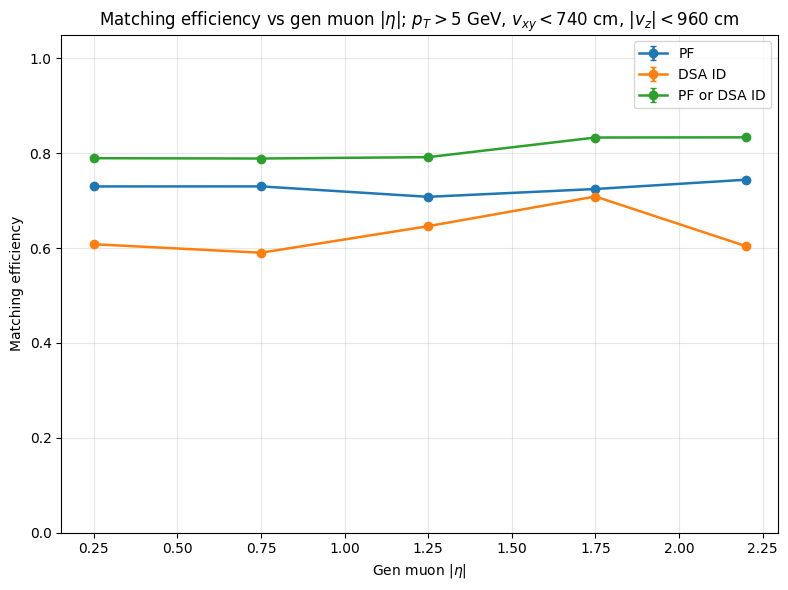

In [11]:
df_eff_abseta = make_efficiency_vs_variable(
    df_match,
    variable="abs_gen_eta",
    bins=BINS["abs_gen_eta"],
    collection="GenParticleLastCopy",
)

plot_efficiency_three_reco_types(
    df_eff_abseta,
    xlabel=r"Gen muon $|\eta|$",
    title=r"Matching efficiency vs gen muon $|\eta|$; $p_T>5$ GeV, $v_{xy}<740$ cm, $|v_z|<960$ cm",
    outname="eff_vs_absEta_DSAID_genCuts",
)

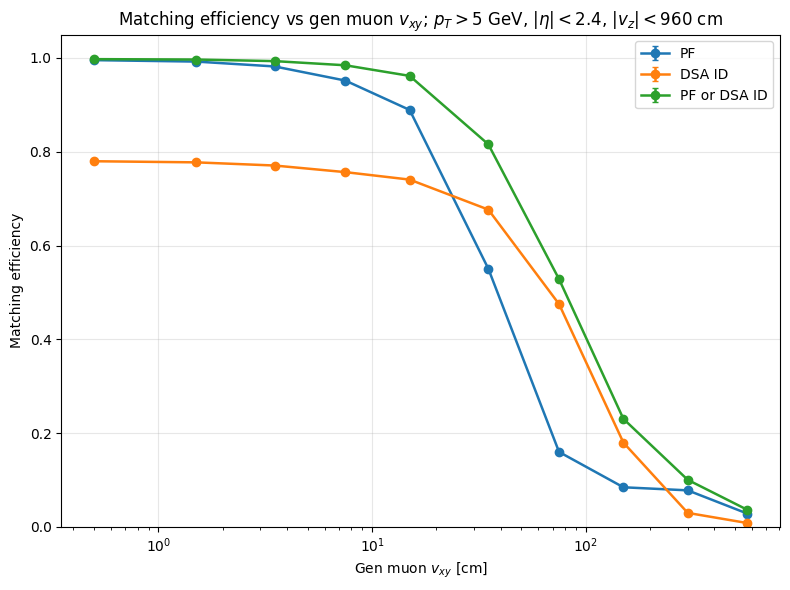

In [12]:
df_eff_vxy = make_efficiency_vs_variable(
    df_match,
    variable="gen_vxy",
    bins=BINS["gen_vxy"],
    collection="GenParticleLastCopy",
)

plot_efficiency_three_reco_types(
    df_eff_vxy,
    xlabel=r"Gen muon $v_{xy}$ [cm]",
    title=r"Matching efficiency vs gen muon $v_{xy}$; $p_T>5$ GeV, $|\eta|<2.4$, $|v_z|<960$ cm",
    outname="eff_vs_genVxy_DSAID_genCuts",
    xscale="log",
)

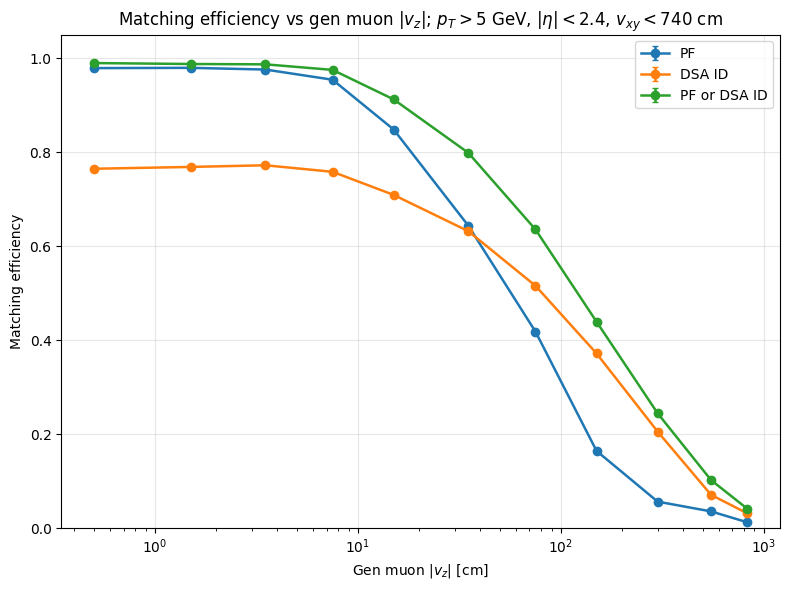

In [13]:
df_eff_absvz = make_efficiency_vs_variable(
    df_match,
    variable="abs_gen_vz",
    bins=BINS["abs_gen_vz"],
    collection="GenParticleLastCopy",
)

plot_efficiency_three_reco_types(
    df_eff_absvz,
    xlabel=r"Gen muon $|v_z|$ [cm]",
    title=r"Matching efficiency vs gen muon $|v_z|$; $p_T>5$ GeV, $|\eta|<2.4$, $v_{xy}<740$ cm",
    outname="eff_vs_absVz_DSAID_genCuts",
    xscale="log",
)

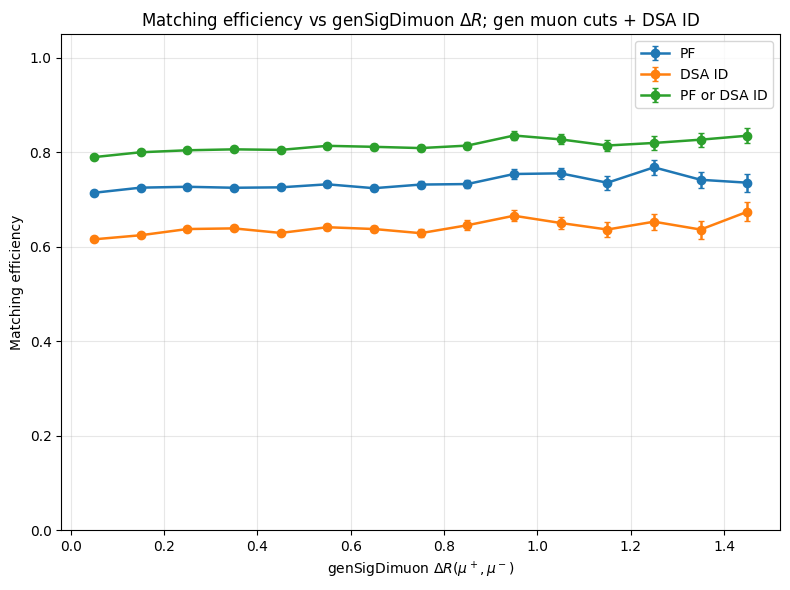

In [14]:
df_eff_dimuon_dr = make_efficiency_vs_variable(
    df_match,
    variable="genSigDimuon_dr",
    bins=BINS["genSigDimuon_dr"],
    collection="GenParticleLastCopy",
)

plot_efficiency_three_reco_types(
    df_eff_dimuon_dr,
    xlabel=r"genSigDimuon $\Delta R(\mu^+,\mu^-)$",
    title=r"Matching efficiency vs genSigDimuon $\Delta R$; gen muon cuts + DSA ID",
    outname="eff_vs_genSigDimuonDR_DSAID_genCuts",
)

In [15]:
df_eff_pt.to_pickle(os.path.join(OUTDIR, "df_eff_vs_genPt.pkl"))
df_eff_abseta.to_pickle(os.path.join(OUTDIR, "df_eff_vs_absEta.pkl"))
df_eff_vxy.to_pickle(os.path.join(OUTDIR, "df_eff_vs_genVxy.pkl"))
df_eff_absvz.to_pickle(os.path.join(OUTDIR, "df_eff_vs_absVz.pkl"))
df_eff_dimuon_dr.to_pickle(os.path.join(OUTDIR, "df_eff_vs_genSigDimuonDR.pkl"))

print("Saved efficiency tables to:", OUTDIR)

NameError: name 'df_eff_pt' is not defined

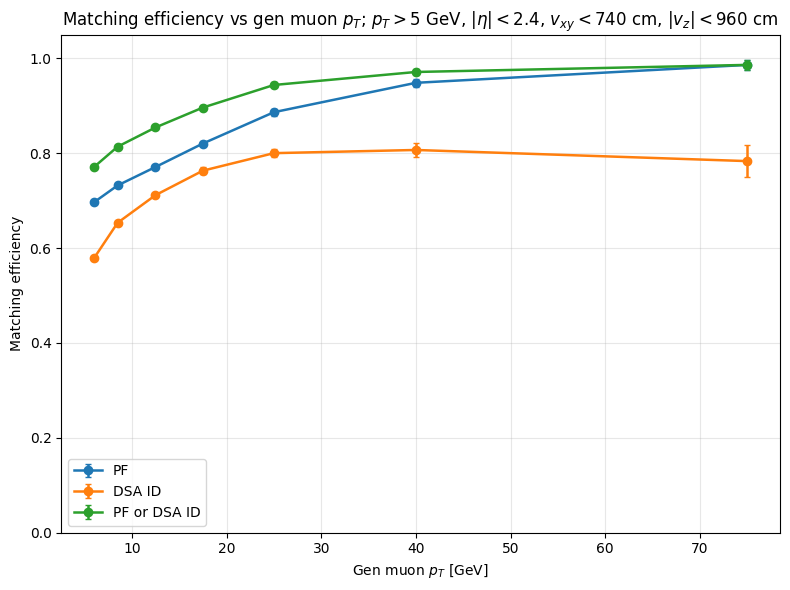

In [16]:
df_eff_pt = make_efficiency_vs_variable(
    df_match,
    variable="gen_pt",
    bins=BINS["gen_pt"],
    collection="GenParticleLastCopy",
)

plot_efficiency_three_reco_types(
    df_eff_pt,
    xlabel=r"Gen muon $p_T$ [GeV]",
    title=r"Matching efficiency vs gen muon $p_T$; $p_T>5$ GeV, $|\eta|<2.4$, $v_{xy}<740$ cm, $|v_z|<960$ cm",
    outname="eff_vs_genPt_DSAID_genCuts",
)

In [17]:
import os
import re
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

AN_OUTDIR = "an_style_plots"
os.makedirs(AN_OUTDIR, exist_ok=True)

def setup_an_mpl_style():
    mpl.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 250,

        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "dejavuserif",

        "axes.linewidth": 1.0,
        "axes.labelsize": 12,
        "axes.titlesize": 12,

        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "xtick.major.width": 0.9,
        "ytick.major.width": 0.9,
        "xtick.minor.width": 0.7,
        "ytick.minor.width": 0.7,

        "legend.frameon": False,
        "legend.fontsize": 9,

        "figure.facecolor": "white",
        "axes.facecolor": "white",
    })

setup_an_mpl_style()


def root_like_axis(ax):
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.minorticks_on()
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


def mass_point_key(sample):
    return re.sub(r"_ctau-[0-9p]+$", "", str(sample))


def pstr_to_float(x):
    return float(str(x).replace("p", "."))


def parse_mass_point(key):
    m = re.search(r"Mchi-([0-9p]+)_dMchi-([0-9p]+)", str(key))
    if m is None:
        return None
    m1 = pstr_to_float(m.group(1))
    dm = pstr_to_float(m.group(2))
    m2 = m1 + dm
    return m1, dm, m2


def mass_sort_key(key):
    parsed = parse_mass_point(key)
    if parsed is None:
        return (9999.0, 9999.0)
    m1, dm, m2 = parsed
    return (m1, dm)


def mass_label(key):
    parsed = parse_mass_point(key)
    if parsed is None:
        return str(key)
    m1, dm, m2 = parsed
    return f"({m1:g}, {m2:g}) GeV"


def prepare_an_plot_df(df_match):
    d = df_match.copy()

    d["mass_point"] = d["sample"].map(mass_point_key)
    d["abs_gen_eta"] = d["gen_eta"].abs()

    numeric_cols = [
        "gen_pt",
        "gen_eta",
        "gen_phi",
        "abs_gen_eta",
        "genSigDimuon_dr",
        "matched_DSA",
        "matched_PF",
        "matched_either",
    ]

    for c in numeric_cols:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    return d


def select_eta_region(df, region):
    if region is None or region.lower() in ["all", "inclusive"]:
        return df.copy()

    region = region.lower()

    if region == "barrel":
        return df[df["gen_eta"].abs() < 1.2].copy()

    if region == "endcap":
        return df[(df["gen_eta"].abs() >= 1.2) & (df["gen_eta"].abs() < 2.4)].copy()

    raise ValueError("region must be one of: None, 'all', 'barrel', 'endcap'")


def clopper_pearson_eff_errors(n_pass, n_tot, cl=0.682689492137):
    n_pass = int(n_pass)
    n_tot = int(n_tot)

    if n_tot <= 0:
        return np.nan, np.nan, np.nan

    eff = n_pass / n_tot

    try:
        lo = ROOT.TEfficiency.ClopperPearson(n_tot, n_pass, cl, False)
        hi = ROOT.TEfficiency.ClopperPearson(n_tot, n_pass, cl, True)
        return eff, eff - lo, hi - eff
    except Exception:
        err = np.sqrt(eff * (1.0 - eff) / n_tot)
        return eff, err, err


def efficiency_points(df, variable, bins, match_col="matched_DSA", min_den=1):
    x = pd.to_numeric(df[variable], errors="coerce").to_numpy(dtype=float)
    m = pd.to_numeric(df[match_col], errors="coerce").fillna(0).to_numpy(dtype=int)

    good = np.isfinite(x)
    x = x[good]
    m = m[good]

    den, _ = np.histogram(x, bins=bins)
    num, _ = np.histogram(x[m == 1], bins=bins)

    centers = 0.5 * (bins[:-1] + bins[1:])
    xerr = 0.5 * (bins[1:] - bins[:-1])

    eff = []
    err_low = []
    err_high = []

    for n_pass, n_tot in zip(num, den):
        e, el, eh = clopper_pearson_eff_errors(n_pass, n_tot)
        eff.append(e)
        err_low.append(el)
        err_high.append(eh)

    eff = np.array(eff)
    err_low = np.array(err_low)
    err_high = np.array(err_high)

    keep = den >= min_den

    return {
        "x": centers[keep],
        "xerr": xerr[keep],
        "y": eff[keep],
        "yerr_low": err_low[keep],
        "yerr_high": err_high[keep],
        "den": den[keep],
        "num": num[keep],
    }


df_an = prepare_an_plot_df(df_match)

available_mass_points = sorted(df_an["mass_point"].unique(), key=mass_sort_key)
print("Available mass points:")
for mp in available_mass_points:
    print(" ", mp, " -> ", mass_label(mp))

Available mass points:
  Mchi-5p25_dMchi-0p5  ->  (5.25, 5.75) GeV
  Mchi-10p5_dMchi-1p0  ->  (10.5, 11.5) GeV
  Mchi-21p0_dMchi-2p0  ->  (21, 23) GeV
  Mchi-31p5_dMchi-3p0  ->  (31.5, 34.5) GeV
  Mchi-42p0_dMchi-4p0  ->  (42, 46) GeV


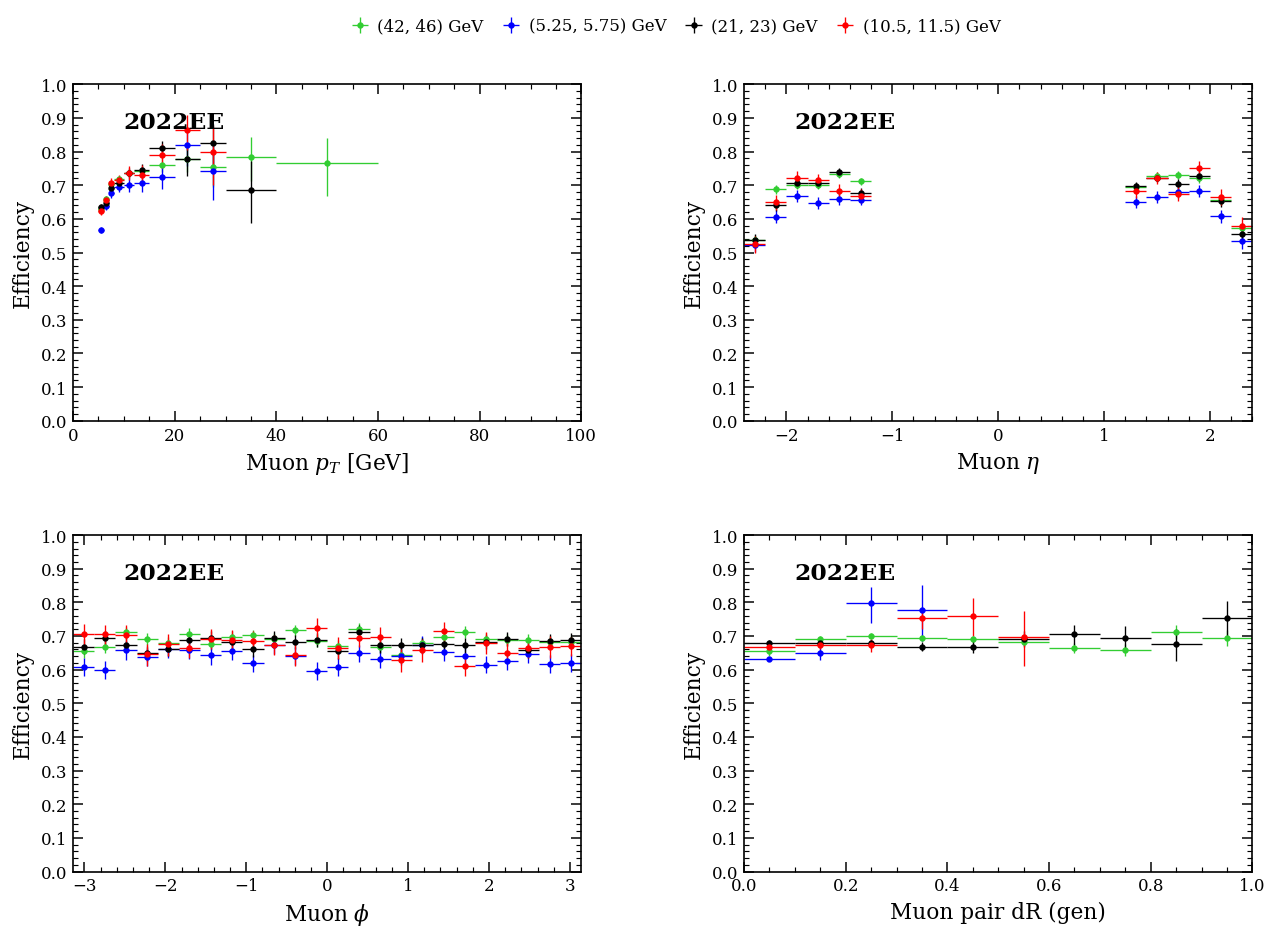

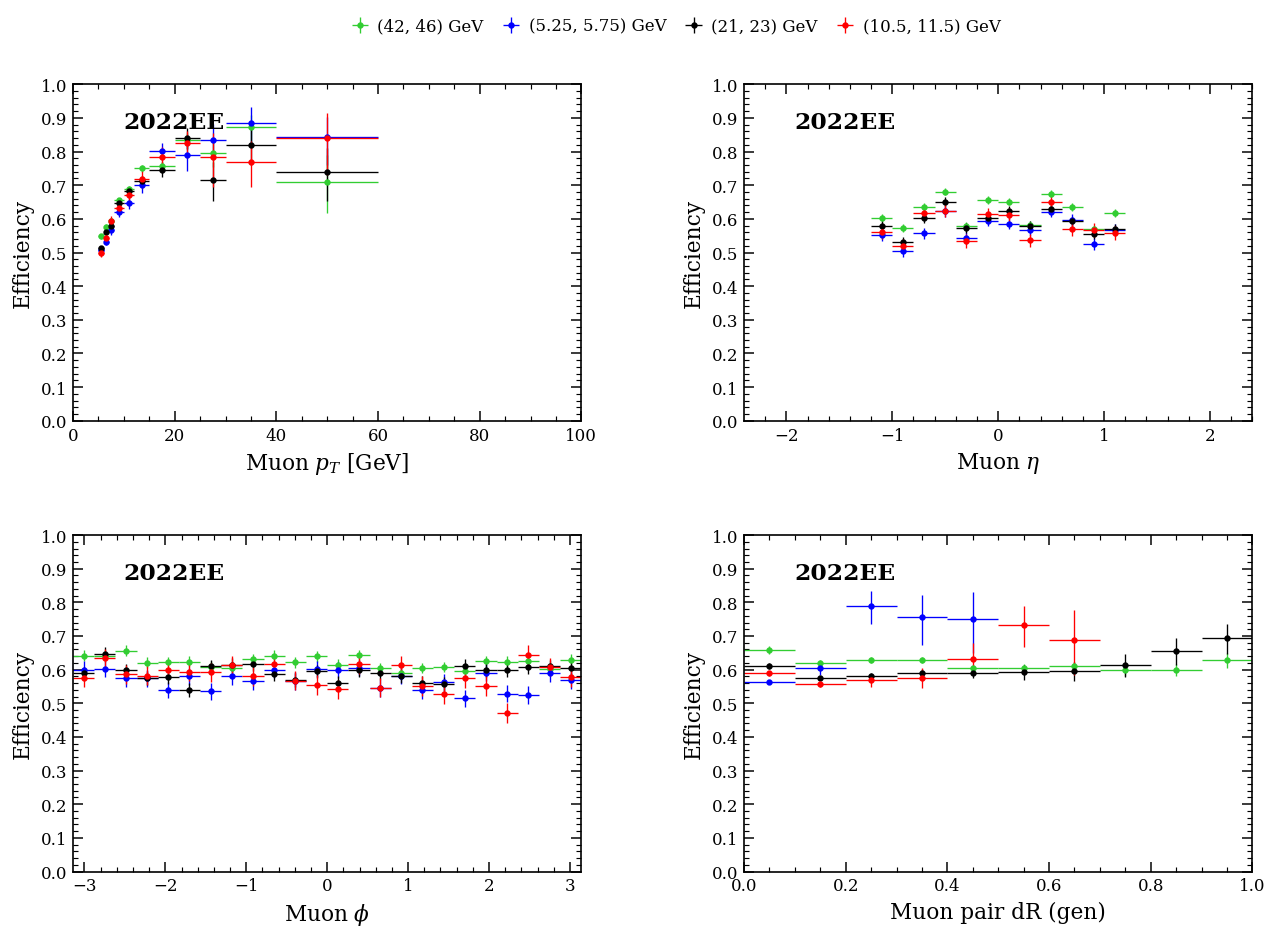

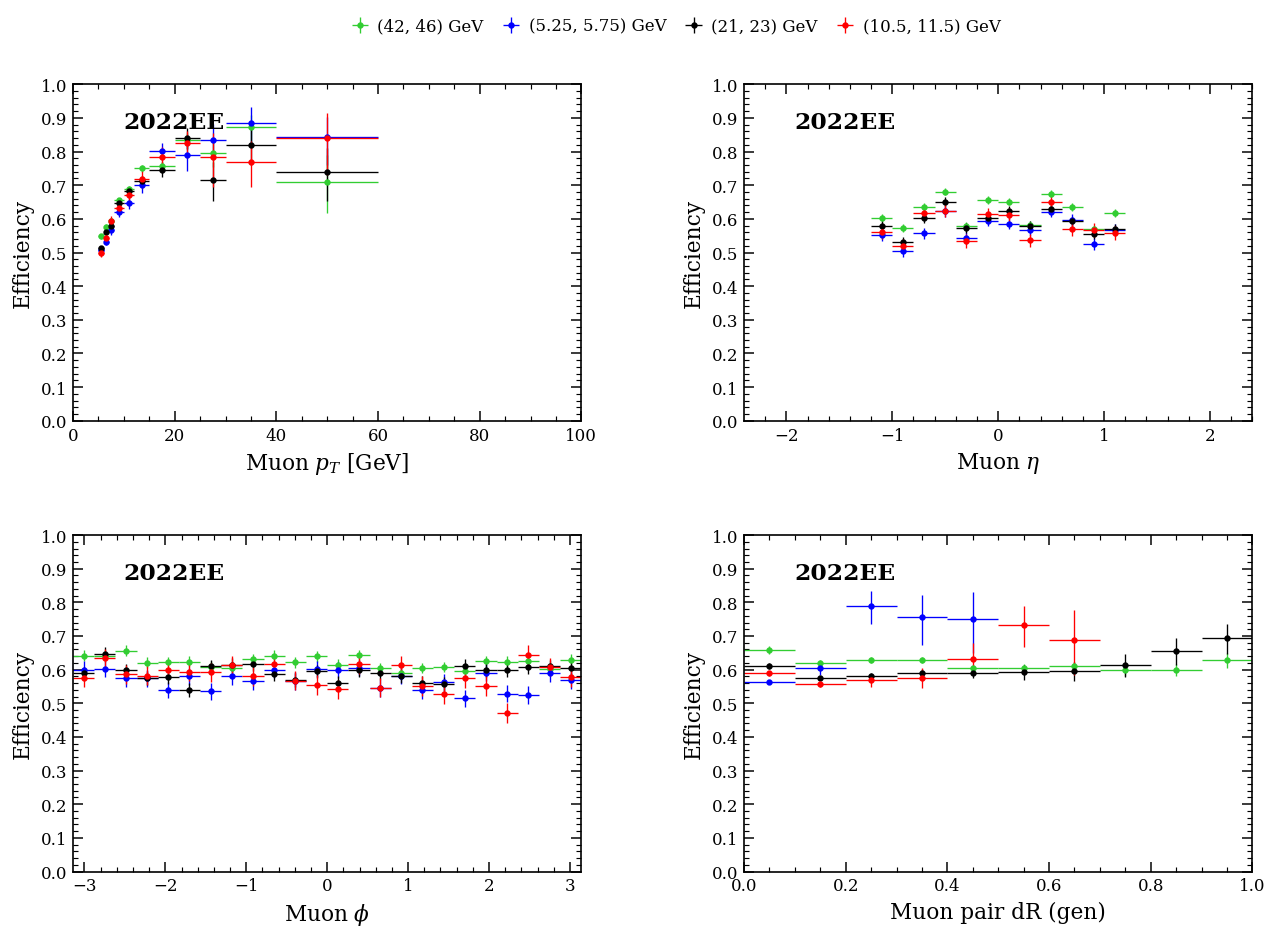

In [18]:
PT_BINS  = np.array([5, 6, 7, 8, 10, 12, 15, 20, 25, 30, 40, 60, 80, 100])
ETA_BINS = np.linspace(-2.4, 2.4, 25)
PHI_BINS = np.linspace(-np.pi, np.pi, 25)
DR_BINS  = np.linspace(0.0, 1.0, 11)

LINE_COLORS = ["limegreen", "blue", "black", "red", "orange", "purple"]
LINE_MARKERS = ["o", "o", "o", "o", "s", "D"]


def plot_reco_efficiency_grid(
    df,
    mass_points,
    region="endcap",
    match_col="matched_DSA",
    year_label="2022EE",
    outname="dsa_efficiency_grid_an_style",
    min_den=25,
):
    d = select_eta_region(df, region)

    fig = plt.figure(figsize=(10.8, 8.0))

    gs = fig.add_gridspec(
        2,
        2,
        left=0.075,
        right=0.985,
        bottom=0.08,
        top=0.90,
        wspace=0.32,
        hspace=0.34,
    )

    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
    ]

    specs = [
        {
            "var": "gen_pt",
            "bins": PT_BINS,
            "xlabel": r"Muon $p_T$ [GeV]",
            "xlim": (0, 100),
        },
        {
            "var": "gen_eta",
            "bins": ETA_BINS,
            "xlabel": r"Muon $\eta$",
            "xlim": (-2.4, 2.4),
        },
        {
            "var": "gen_phi",
            "bins": PHI_BINS,
            "xlabel": r"Muon $\phi$",
            "xlim": (-np.pi, np.pi),
        },
        {
            "var": "genSigDimuon_dr",
            "bins": DR_BINS,
            "xlabel": r"Muon pair dR (gen)",
            "xlim": (0, 1.0),
        },
    ]

    legend_handles = []
    legend_labels = []

    for ax, spec in zip(axes, specs):
        root_like_axis(ax)

        for i, mp in enumerate(mass_points):
            ds = d[d["mass_point"] == mp]

            if len(ds) == 0:
                continue

            pts = efficiency_points(
                ds,
                variable=spec["var"],
                bins=spec["bins"],
                match_col=match_col,
                min_den=min_den,
            )

            if len(pts["x"]) == 0:
                continue

            handle = ax.errorbar(
                pts["x"],
                pts["y"],
                xerr=pts["xerr"],
                yerr=np.vstack([pts["yerr_low"], pts["yerr_high"]]),
                fmt=LINE_MARKERS[i % len(LINE_MARKERS)],
                markersize=2.8,
                elinewidth=0.8,
                capsize=0,
                linestyle="none",
                color=LINE_COLORS[i % len(LINE_COLORS)],
                label=mass_label(mp),
            )

            if spec["var"] == "gen_pt":
                legend_handles.append(handle)
                legend_labels.append(mass_label(mp))

        ax.set_xlabel(spec["xlabel"], fontsize=13)
        ax.set_ylabel("Efficiency", fontsize=13)

        ax.set_xlim(*spec["xlim"])
        ax.set_ylim(0.0, 1.0)
        ax.set_yticks(np.linspace(0, 1, 11))

        ax.tick_params(axis="both", which="major", labelsize=10)
        ax.tick_params(axis="both", which="minor", labelsize=10)

        ax.text(
            0.10,
            0.92,
            year_label,
            transform=ax.transAxes,
            fontsize=14,
            fontweight="bold",
            va="top",
        )

    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.54, 0.985),
        ncol=len(legend_labels),
        frameon=False,
        fontsize=10,
        handlelength=1.1,
        handletextpad=0.5,
        columnspacing=1.1,
    )

    fig.savefig(os.path.join(AN_OUTDIR, outname + ".png"))
    fig.savefig(os.path.join(AN_OUTDIR, outname + ".pdf"))

    plt.show()
    return fig

# Change this list to whatever four mass points you want in the legend.
selected_mass_points = [
    "Mchi-42p0_dMchi-4p0",
    "Mchi-5p25_dMchi-0p5",
    "Mchi-21p0_dMchi-2p0",
    "Mchi-10p5_dMchi-1p0",
]

selected_mass_points = [mp for mp in selected_mass_points if mp in available_mass_points]

# Fallback if one of the above names is absent.
if len(selected_mass_points) == 0:
    selected_mass_points = available_mass_points[:4]

plot_reco_efficiency_grid(
    df_an,
    selected_mass_points,
    region="endcap",
    match_col="matched_DSA",
    year_label="2022EE",
    outname="dsa_id_efficiency_endcap_an_style",
)

plot_reco_efficiency_grid(
    df_an,
    selected_mass_points,
    region="barrel",
    match_col="matched_DSA",
    year_label="2022EE",
    outname="dsa_id_efficiency_barrel_an_style",
)

In [ ]:
def nice_upper(x, step, minimum, maximum):
    if not np.isfinite(x):
        return minimum
    return min(maximum, max(minimum, step * np.ceil(x / step)))


def plot_gen_pt_vs_dimuon_dr_grid(
    df,
    mass_points,
    region="all",
    outname="gen_pt_vs_dimuon_dr_an_style",
    annotate_sample=True,
):
    d = select_eta_region(df, region)

    fig, axes = plt.subplots(2, 2, figsize=(10.8, 8.2))
    axes = axes.flatten()

    cmap = copy.copy(plt.get_cmap("viridis"))
    cmap.set_bad("white")

    for ax, mp in zip(axes, mass_points):
        root_like_axis(ax)

        ds = d[d["mass_point"] == mp].copy()

        if len(ds) == 0:
            ax.axis("off")
            continue

        x = pd.to_numeric(ds["genSigDimuon_dr"], errors="coerce").to_numpy(dtype=float)
        y = pd.to_numeric(ds["gen_pt"], errors="coerce").to_numpy(dtype=float)

        good = np.isfinite(x) & np.isfinite(y)
        x = x[good]
        y = y[good]

        dr_upper = nice_upper(np.nanpercentile(x, 99.5), step=0.5, minimum=1.0, maximum=5.0)
        pt_upper = nice_upper(np.nanpercentile(y, 99.5), step=10.0, minimum=50.0, maximum=250.0)

        dr_bins = np.linspace(0.0, dr_upper, 45)
        pt_bins = np.linspace(0.0, pt_upper, 50)

        h, xedges, yedges = np.histogram2d(x, y, bins=[dr_bins, pt_bins])
        h = h.T
        h = np.ma.masked_where(h <= 0, h)

        mesh = ax.pcolormesh(
            xedges,
            yedges,
            h,
            cmap=cmap,
            shading="auto",
        )

        cbar = fig.colorbar(mesh, ax=ax, pad=0.015)
        cbar.set_label("Events", rotation=270, labelpad=16)
        cbar.ax.tick_params(which="both", direction="in")

        ax.set_xlabel(r"Muon pair dR (gen)")
        ax.set_ylabel(r"Muon $p_T$ (gen) [GeV]")

        ax.set_xlim(0.0, dr_upper)
        ax.set_ylim(0.0, pt_upper)

        if annotate_sample:
            ax.text(
                0.06,
                0.93,
                mass_label(mp),
                transform=ax.transAxes,
                fontsize=12,
                fontweight="bold",
                va="top",
            )

    for ax in axes[len(mass_points):]:
        ax.axis("off")

    fig.subplots_adjust(left=0.08, right=0.96, bottom=0.08, top=0.98, wspace=0.34, hspace=0.30)

    fig.savefig(os.path.join(AN_OUTDIR, outname + ".png"))
    fig.savefig(os.path.join(AN_OUTDIR, outname + ".pdf"))

    plt.show()
    return fig


plot_gen_pt_vs_dimuon_dr_grid(
    df_an,
    selected_mass_points[:4],
    region="all",
    outname="gen_pt_vs_dimuon_dr_an_style",
)